# Working with a neural network

So far, every model you used had a formula that *you* chose: a line $a = cT$, a parabola, a power
law. You only had to tune a few parameters to minimise the loss.

A **neural network** is a much more flexible model. It is built from many small units ("neurons")
connected by adjustable numbers called **weights**. You do *not* choose a formula: instead the
computer tunes *all* of the weights automatically, to make the loss as small as possible. This
tuning is called **training**, and it works by gradient descent — the same step-by-step "move in
the direction that lowers the loss" idea you reasoned about in Section 2, but now for many
parameters at once.

In this notebook we train a small neural network to predict the semi-major axis $a$ from the
orbital period $T$, and compare it with the power law you found in Section 3.

## How to use this notebook

New to Google Colab? A few basics:

- **Run a cell** by clicking it and pressing **Shift + Enter** (or click the **▶** button on its left).
- **Run the cells in order, from top to bottom.** A cell often needs things set up by the cells above it, so if you skip one you may get an error (for example a `NameError`).
- The first time you run something, Colab may warn that the notebook **was not authored by Google**. Click **Run anyway**; this notebook only does calculations and makes plots.
- If a cell shows a **red error**, read the **last line**, fix it (or ask your AI tutor) and run the cell again.
- Anything you type or produce here is temporary, which is fine for this lesson.


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

## The data

The same eight planets as before: period $T$ (years) and semi-major axis $a$ (AU).

In [2]:
planets = pd.DataFrame({
    "planet":  ["Mercury","Venus","Earth","Mars","Jupiter","Saturn","Uranus","Neptune"],
    "T_years": [0.2408467, 0.61519726, 1.0000174, 1.8808158, 11.862615, 29.447498, 84.016846, 164.79132],
    "a_au":    [0.38709893, 0.72333199, 1.00000011, 1.52366231, 5.20336301, 9.53707032, 19.19126393, 30.06896348],
})
planets

,planet,T_years,a_au
0,Mercury,0.240847,0.387099
1,Venus,0.615197,0.723332
2,Earth,1.000017,1.000000
3,Mars,1.880816,1.523662
4,Jupiter,11.862615,5.203363
5,Saturn,29.447498,9.537070
6,Uranus,84.016846,19.191264
7,Neptune,164.791320,30.068963


## Preparing the data: scaling

Neural networks train much better when the input and output numbers are roughly in the range
$-1$ to $1$. Our periods run from $0.24$ up to $165$ years — a huge range. So we first **scale**
the data (subtract the mean, divide by the standard deviation) with a `StandardScaler`, and undo
the scaling afterwards when we want real values back.

In [3]:
X = planets[["T_years"]].values     # input:  orbital period
y = planets["a_au"].values          # target: semi-major axis

x_scaler = StandardScaler().fit(X)
y_scaler = StandardScaler().fit(y.reshape(-1, 1))

X_scaled = x_scaler.transform(X)
y_scaled = y_scaler.transform(y.reshape(-1, 1)).ravel()

## Build and train the network

We use a small network with **one hidden layer of 8 neurons** and a smooth (`tanh`) activation.
`MLPRegressor` builds the network and trains it for us.

In [4]:
nn = MLPRegressor(
    hidden_layer_sizes=(8,),
    activation="tanh",
    solver="lbfgs",
    max_iter=5000,
    random_state=0,
)
nn.fit(X_scaled, y_scaled)

n_params = sum(w.size for w in nn.coefs_) + sum(b.size for b in nn.intercepts_)
print(f"training finished — the network has {n_params} weights")

training finished — the network has 25 weights


## How well does it fit?

We let the trained network predict $a$ across the whole range of periods and plot the curve on
top of the data.

neural network MSE on all 8 planets = 0.0108


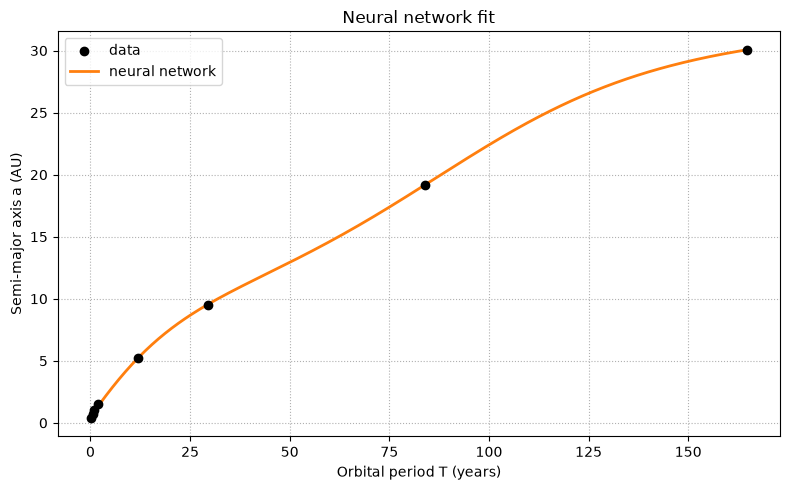

In [5]:
def nn_predict(T_values):
    Xs = x_scaler.transform(np.asarray(T_values, dtype=float).reshape(-1, 1))
    ys = nn.predict(Xs)
    return y_scaler.inverse_transform(ys.reshape(-1, 1)).ravel()

def mse(true, pred):
    return np.mean((np.asarray(true) - np.asarray(pred)) ** 2)

a_pred = nn_predict(planets["T_years"].values)
print(f"neural network MSE on all 8 planets = {mse(planets['a_au'].values, a_pred):.4f}")

T_line = np.linspace(0, planets["T_years"].max(), 300)
plt.figure(figsize=(8, 5))
plt.scatter(planets["T_years"], planets["a_au"], color="black", zorder=5, label="data")
plt.plot(T_line, nn_predict(T_line), color="tab:orange", linewidth=2, label="neural network")
plt.xlabel("Orbital period T (years)")
plt.ylabel("Semi-major axis a (AU)")
plt.title("Neural network fit")
plt.grid(True, linestyle=":")
plt.legend()
plt.tight_layout()
plt.show()

## Compare with the power law from Section 3

Let's put the neural network next to the power-law model, using the same loss.

In [6]:
T = planets["T_years"].values
a = planets["a_au"].values

# power-law fit (as in Section 3): a straight line in log-log space
p, logC = np.polyfit(np.log(T), np.log(a), 1)
C = np.exp(logC)
a_power = C * T ** p

pd.DataFrame({
    "model":        ["power law  a = C T^p", "neural network"],
    "MSE":          [mse(a, a_power), mse(a, a_pred)],
    "# parameters": [2, n_params],
})

,model,MSE,# parameters
0,power law a = C T^p,8.683012e-07,2
1,neural network,1.084509e-02,25


### What this tells us

- The neural network can bend to follow the data reasonably well — not bad for a model that was
  never told the shape of the relation.
- But the **power law still wins**: with only **2 parameters** it fits essentially perfectly,
  while the network needs about **25 weights** and does slightly worse.
- And crucially, the power law is **interpretable**: its exponent $p \approx 2/3$ *means*
  something (we will see what in the next section). The network's 25 weights are just numbers —
  they hide the relationship instead of revealing it.

**When is each one useful?** When you suspect there is a clean underlying law (as here), a simple
model with the right shape is better: accurate *and* interpretable. When you have lots of data and
no idea of the formula, the flexibility of a neural network becomes a real advantage.

## Things to try (extensions)

Run the cells below to explore how the network changes. This helper trains a network of a given
size and activation and returns a prediction function.

In [7]:
def train_nn(hidden=(8,), activation="tanh", seed=0):
    m = MLPRegressor(hidden_layer_sizes=hidden, activation=activation,
                     solver="lbfgs", max_iter=5000, random_state=seed)
    m.fit(X_scaled, y_scaled)
    def predict(T_values):
        Xs = x_scaler.transform(np.asarray(T_values, dtype=float).reshape(-1, 1))
        return y_scaler.inverse_transform(m.predict(Xs).reshape(-1, 1)).ravel()
    return predict

### 1. Change the size of the network

Bigger networks have more weights and can bend more. Does the fit keep improving?

In [ ]:
configs = [(2,), (8,), (16,), (8, 8)]     # <- try changing these network sizes
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, hidden in zip(axes.flat, configs):
    predict = train_nn(hidden=hidden)
    ax.scatter(T, a, color="black", zorder=5)
    ax.plot(T_line, predict(T_line), color="tab:orange", linewidth=2)
    ax.set_title(f"hidden = {hidden}   MSE = {mse(a, predict(T)):.3f}")
    ax.set_xlabel("T (years)")
    ax.set_ylabel("a (AU)")
    ax.grid(True, linestyle=":")
fig.tight_layout()
plt.show()


### 2. Change the activation function

The activation sets the "shape" the neurons can make. Notice how `relu` gives straight pieces
with kinks, while `tanh` and `logistic` give smooth curves.

In [ ]:
activations = ["tanh", "relu", "logistic"]     # <- try changing these activations
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, act in zip(axes, activations):
    predict = train_nn(hidden=(8,), activation=act)
    ax.scatter(T, a, color="black", zorder=5)
    ax.plot(T_line, predict(T_line), color="tab:orange", linewidth=2)
    ax.set_title(f"activation = '{act}'   MSE = {mse(a, predict(T)):.3f}")
    ax.set_xlabel("T (years)")
    ax.set_ylabel("a (AU)")
    ax.grid(True, linestyle=":")
fig.tight_layout()
plt.show()


### 3. Your turn

- Which network size gave the lowest loss? Did making it bigger always help?
- Which activation followed the data best?
- Even the best network needs many more parameters than the power law. Which model would you trust
  to predict the orbit of a *new* planet far outside our data, and why?